## Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Importing the dataset

In [2]:
dataset = pd.read_csv("F:\MA Team\First Dataset.csv")

In [3]:
dataset.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


## Droping the missing values by dropna() method

In [4]:
dataset = dataset.dropna()

## Checking and removing duplicates

In [5]:
dataset.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
48    False
49    False
50    False
51    False
52    False
53    False
54    False
55    False
56    False
57    False
58    False
59    False
60     True
dtype: bool

In [6]:
dataset = dataset.drop_duplicates()

## Fixing 'gender' column problem

In [7]:
unique_names = {
    "Ali": "M",
    "Amir": "M",
    "Maryam": "F",
    "Kimia": "F",
    "Mina": "F",
    "Sara": "F",
    "Reza": "M",
    "Sina": "M",
    "Arash": "M",
    "Parsa": "M",
    "Neda": "F",
    "Zahra": "M",
}

In [8]:
dataset['gender'] = dataset['first_name'].map(unique_names)
dataset

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,M,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,F,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4
5,1006,Amir,M,58.0,Mashhad,Khorasan,2022-01-26,Gold,35,110.53,3868.55,205,Cash,Android,Yes,5,2
6,1007,Reza,M,43.0,Rasht,Gilan,2025-09-09,VIP,29,77.15,2237.35,298,Cash,iPhone,Yes,2,5
7,1008,Reza,M,23.0,Rasht,Gilan,2024-10-03,VIP,3,389.58,1168.74,195,Online Wallet,iPhone,No,8,1
8,1009,Kimia,F,61.0,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,No,8,2
9,1010,Arash,M,145.0,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.47,276,Online Wallet,Android,No,7,1


## Outliers

### Detecting outliers

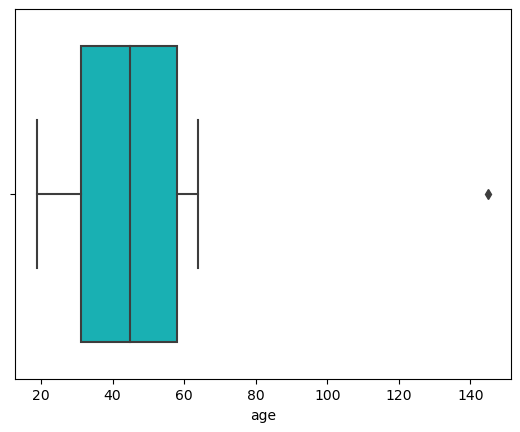

In [9]:
sns.boxplot(data=dataset, x='age', color='#00c9cc')
plt.show()

### IQR method for removing outliers

In [10]:
q1 = dataset['age'].quantile(0.25)
q3 = dataset['age'].quantile(0.75)
iqr = q3 - q1
print(q1, q3, iqr)

31.25 58.0 26.75


### Defining outliers based on IQR

In [11]:
upper_limit = q3 + (1.5 * iqr)
lower_limit = q1 - (1.5 * iqr)
print(upper_limit, lower_limit)

98.125 -8.875


In [12]:
outlier = dataset.loc[(dataset['age'] > upper_limit) | (dataset['age'] < lower_limit)]
outlier

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
9,1010,Arash,M,145.0,Karaj,Alborz,2022-06-25,Silver,19,381.13,7241.47,276,Online Wallet,Android,No,7,1


### Filtering the dataset to exclude outliers

In [13]:
final_dataset = dataset.drop(outlier.index)
final_dataset

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,M,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,F,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4
5,1006,Amir,M,58.0,Mashhad,Khorasan,2022-01-26,Gold,35,110.53,3868.55,205,Cash,Android,Yes,5,2
6,1007,Reza,M,43.0,Rasht,Gilan,2025-09-09,VIP,29,77.15,2237.35,298,Cash,iPhone,Yes,2,5
7,1008,Reza,M,23.0,Rasht,Gilan,2024-10-03,VIP,3,389.58,1168.74,195,Online Wallet,iPhone,No,8,1
8,1009,Kimia,F,61.0,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,No,8,2
10,1011,Neda,F,41.0,Karaj,Alborz,2021-12-16,Bronze,19,119.16,2264.04,272,Card,Android,No,8,2


## Reseting index

In [14]:
final_dataset = final_dataset.reset_index(drop=True)
final_dataset

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,M,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,M,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,M,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,F,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4
5,1006,Amir,M,58.0,Mashhad,Khorasan,2022-01-26,Gold,35,110.53,3868.55,205,Cash,Android,Yes,5,2
6,1007,Reza,M,43.0,Rasht,Gilan,2025-09-09,VIP,29,77.15,2237.35,298,Cash,iPhone,Yes,2,5
7,1008,Reza,M,23.0,Rasht,Gilan,2024-10-03,VIP,3,389.58,1168.74,195,Online Wallet,iPhone,No,8,1
8,1009,Kimia,F,61.0,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,No,8,2
9,1011,Neda,F,41.0,Karaj,Alborz,2021-12-16,Bronze,19,119.16,2264.04,272,Card,Android,No,8,2


## Exporting cleaned_dataset in xlsx format

In [15]:
final_dataset.to_excel(r'C:\Users\Asus\Downloads\cleaned_dataset_nana-in-wonderland.xlsx', index=False)

## Top 5 customers based on 'total_spending'

In [16]:
sorted_final_dataset = dataset.sort_values(by='total_spending', ascending=False)

In [17]:
sorted_final_dataset.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
29,1030,Sina,M,60.0,Mashhad,Khorasan,2025-03-07,VIP,26,156.89,25000.00,340,Cash,Web,Yes,4,4
43,1044,Mina,F,64.0,Shiraz,Fars,2024-07-27,Gold,33,434.98,14354.34,165,Card,Android,No,7,2
56,1057,Maryam,F,58.0,Ahvaz,Khuzestan,2024-06-11,Bronze,31,436.54,13532.74,82,Cash,iPhone,No,4,4
11,1012,Arash,M,51.0,Mashhad,Khorasan,2023-07-22,Gold,27,434.50,11731.50,224,Online Wallet,iPhone,Yes,3,2
8,1009,Kimia,F,61.0,Karaj,Alborz,2021-05-14,Silver,34,341.63,11615.42,232,Card,Web,No,8,2


## Which cities have more 'total_spending'?

#### *using double brackets returns a DataFrame*

In [18]:
city_grouped = final_dataset.groupby("city")[["total_spending"]].sum()

In [19]:
city_grouped.sort_values("total_spending", ascending=False)

,total_spending
city,
Mashhad,64118.44
Tabriz,36192.49
Ahvaz,23384.78
Shiraz,20715.92
Isfahan,18980.60
Karaj,18948.34
Rasht,15168.54
Tehran,13880.85


## Which payment mothod was used the most?

In [20]:
payment_method_grouped = final_dataset.groupby("payment_method")[["purchase_count"]].sum()

In [21]:
payment_method_grouped.sort_values("purchase_count", ascending=False)

,purchase_count
payment_method,
Cash,349
Online Wallet,321
Card,304


## Sorting devices based on 'total_spending'?

In [22]:
device_grouped = final_dataset.groupby("device")[["total_spending"]].sum()

In [23]:
device_grouped.sort_values("total_spending", ascending=False)

,total_spending
device,
Web,75881.34
iPhone,67931.01
Android,67577.61


## 'discount_used' VS. 'satisfaction_score'

In [24]:
discount_grouped = final_dataset.groupby("discount_used")[["purchase_count"]].sum()

In [25]:
discount_grouped.sort_values("purchase_count", ascending=False)

,purchase_count
discount_used,
No,569
Yes,405


In [26]:
satisfaction_grouped = final_dataset.groupby("discount_used")[["satisfaction_score"]].sum()

In [27]:
satisfaction_grouped.sort_values("discount_used", ascending=False)

,satisfaction_score
discount_used,
Yes,78
No,93


## Time series:
## During which time periods were sales higher?

### Ensuring about signup_date type:

In [28]:
final_dataset["signup_date"] = pd.to_datetime(final_dataset["signup_date"])

In [29]:
final_dataset["month"] = final_dataset["signup_date"].dt.month_name()
monthly_spending = final_dataset.groupby("month")["total_spending"].sum()

In [30]:
monthly_spending = monthly_spending.sort_values(ascending=False)
monthly_spending

month
July         32928.56
March        30383.00
May          25074.58
August       20519.29
June         20145.27
February     17507.32
November     16850.44
January      13436.07
September    13392.82
October       9902.92
December      7920.77
April         3328.92
Name: total_spending, dtype: float64

# The last step:
## A statistical summary of the cleaned dataset

In [31]:
final_dataset.describe()

,customer_id,age,purchase_count,avg_order_value,total_spending,last_purchase_days,returned_items,satisfaction_score
count,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000,57.000000
mean,1030.877193,43.280702,17.087719,213.744386,3708.595789,201.929825,4.210526,3.000000
std,17.609930,14.021354,10.170477,129.919511,4348.282835,95.903571,2.690837,1.414214
min,1001.000000,19.000000,0.000000,27.630000,0.000000,3.000000,0.000000,1.000000
25%,1016.000000,31.000000,10.000000,108.190000,1161.920000,139.000000,2.000000,2.000000
50%,1031.000000,45.000000,17.000000,161.330000,2117.000000,205.000000,4.000000,3.000000
75%,1046.000000,58.000000,24.000000,323.320000,4615.050000,273.000000,7.000000,4.000000
max,1060.000000,64.000000,35.000000,449.810000,25000.000000,365.000000,8.000000,5.000000


## -- Customer Behavior Analysis --

### Total number of customers:

In [32]:
total_customers = len(final_dataset)
total_customers
#count in describe() will give us the same result

57

### Total number of purchases:
#### use sum() to calculate total number in 'purchase_count' column

In [33]:
total_purchases = final_dataset['purchase_count'].sum()
total_purchases

974

## Total revenue
#### use sum() to calculate total number in 'total_spending' column

In [34]:
total_spending = final_dataset['total_spending'].sum()
total_spending

211389.96

## Mean satisfaction_score

In [35]:
mean_satisfaction_score = final_dataset['satisfaction_score'].mean()
mean_satisfaction_score
#mean in describe() will give us the same result

3.0

## Return Rate (%) = (Returned Items / Sold Items) * 100

In [36]:
total_return_items = final_dataset['returned_items'].sum()
total_return_items

240

In [37]:
return_rate = (total_return_items / total_purchases) * 100
return_rate

24.64065708418891

## Average Customer Spend = Total Revenue / Number of Customers
### This metric shows how much revenue each customer generates for the business on average in total

In [38]:
average_customer_spend = total_spending / total_customers
print(average_customer_spend.round(2))

3708.6


## Average Order Value = Total Revenue / Number of Orders
### This metric represents the average value of each order

In [39]:
average_order_value = total_spending / total_purchases
average_order_value

217.03281314168376

## Repeat Purchase = Total Purchases / Total Customers

In [40]:
repeat_purchases = total_purchases / total_customers
repeat_purchases

17.087719298245613

## -------------------- Executive Summary --------------------

#### The average repeat purchase rate indicates that each customer has placed approximately 17 orders, suggesting a high level of customer loyalty and strong customer retention. However, the 24% return rate is considerably high and requires immediate attention. Further investigation should be conducted to identify the underlying causes, such as product quality issues, inaccurate product descriptions, or customer expectation mismatches.
#### The Average Order Value (AOV) is 217, with values ranging from 27.63 to 449.81. This indicates that customers generally tend to place relatively high-value orders, contributing positively to the business's overall revenue.
#### The average customer satisfaction score is 3 out of 5, which represents a moderate level of satisfaction. Although this score is acceptable, it does not fully align with the high repeat purchase rate. Since customers are returning to make additional purchases, improving the overall customer experience should be a priority to maintain their loyalty, increase satisfaction, and reduce the risk of losing valuable customers in the future.

## City Analysis

In [41]:
city_analysis = final_dataset.groupby('city').agg(
customers=('customer_id','nunique'),
revenue=('total_spending','sum'),
average_spending=('total_spending','mean'),
satisfaction=('satisfaction_score','mean'),
purchases=('purchase_count','sum'),
returns=('returned_items','sum'),
)

city_analysis['return_rate'] = (city_analysis['returns'] / city_analysis['purchases']) * 100
city_analysis

,customers,revenue,average_spending,satisfaction,purchases,returns,return_rate
city,,,,,,,
Ahvaz,8,23384.78,2923.097500,3.500000,111,39,35.135135
Isfahan,4,18980.60,4745.150000,4.250000,83,21,25.301205
Karaj,6,18948.34,3158.056667,3.166667,93,27,29.032258
Mashhad,11,64118.44,5828.949091,2.909091,249,29,11.646586
Rasht,5,15168.54,3033.708000,2.600000,82,22,26.829268
Shiraz,6,20715.92,3452.653333,2.000000,98,29,29.591837
Tabriz,12,36192.49,3016.040833,3.000000,189,55,29.100529
Tehran,5,13880.85,2776.170000,2.800000,69,18,26.086957


## City Score

## Step 1:
## Normalize the data:
### Transforming everything into a score between 0 and 1 with Min-Max normalization
## Score = x - min(x) / max(x) - min(x)

In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

columns = [
    'customers',
    'revenue',
    'average_spending',
    'satisfaction',
    'purchases',
    'returns',
    'return_rate'
]

city_analysis[columns] =scaler.fit_transform(city_analysis[columns])
city_analysis

,customers,revenue,average_spending,satisfaction,purchases,returns,return_rate
city,,,,,,,
Ahvaz,0.500,0.189180,0.048129,0.666667,0.233333,0.567568,1.000000
Isfahan,0.000,0.101513,0.644980,1.000000,0.077778,0.081081,0.581331
Karaj,0.250,0.100870,0.125095,0.518519,0.133333,0.243243,0.740176
Mashhad,0.875,1.000000,1.000000,0.404040,1.000000,0.297297,0.000000
Rasht,0.125,0.025632,0.084362,0.266667,0.072222,0.108108,0.646387
Shiraz,0.250,0.136055,0.221596,0.000000,0.161111,0.297297,0.764000
Tabriz,1.000,0.444122,0.078575,0.444444,0.666667,1.000000,0.743083
Tehran,0.125,0.000000,0.000000,0.355556,0.000000,0.000000,0.614783


## Step 2:
## Choosing weights
### Weights represents business priorities 

In [43]:
weights = {
    "revenue": 0.3,
    "customers": 0.2,
    "satisfaction": 0.20,
    "average_spending": 0.15,
    "return_rate": 0.15
}

## Step 3:
## Calculating the final city score
### All the weights are possitive except return_rate

In [44]:
city_analysis['city_score'] = (
    city_analysis["revenue"] * 0.3 +
    city_analysis["customers"] * 0.2 +
    city_analysis["satisfaction"] * 0.2 +
    city_analysis["average_spending"] * 0.15 -
    city_analysis["return_rate"] * 0.15
)

city_analysis.sort_values(
    "city_score", ascending=False
)

,customers,revenue,average_spending,satisfaction,purchases,returns,return_rate,city_score
city,,,,,,,,
Mashhad,0.875,1.000000,1.000000,0.404040,1.000000,0.297297,0.000000,0.705808
Tabriz,1.000,0.444122,0.078575,0.444444,0.666667,1.000000,0.743083,0.322449
Isfahan,0.000,0.101513,0.644980,1.000000,0.077778,0.081081,0.581331,0.240001
Ahvaz,0.500,0.189180,0.048129,0.666667,0.233333,0.567568,1.000000,0.147307
Karaj,0.250,0.100870,0.125095,0.518519,0.133333,0.243243,0.740176,0.091703
Shiraz,0.250,0.136055,0.221596,0.000000,0.161111,0.297297,0.764000,0.009456
Tehran,0.125,0.000000,0.000000,0.355556,0.000000,0.000000,0.614783,0.003894
Rasht,0.125,0.025632,0.084362,0.266667,0.072222,0.108108,0.646387,0.001719


## -------------------- City Analysis Summary --------------------

## Chosen city for advertisement: Mashhad

#### The reason for selecting Mashhad is that it generated the highest revenue for the company while also having one of the highest numbers of customers among all cities. Additionally, it has the lowest return rate, which indicates better purchasing performance and suggests that customers are less likely to make incorrect purchase decisions.
#### However, there is still a potential risk because customer satisfaction in Mashhad is at an average level and it is not among the cities with the highest satisfaction rates. Nevertheless, this could potentially be improved by designing and implementing an effective advertising campaign focused on enhancing customer experience and satisfaction.

## 10 Customers for Loyalty Campaign

#### This is our workflow:
#### Step 1: Converting categorical variables into numeric values
#### Step 2: Normalizing the numeric features
#### Step 3: Choosing weights based on business priorities
#### Step 4: Calculating a final customer score
#### Step5: Ranking customers and selecting top 10

## Step 1

In [45]:
membership_score = {
    "Bronze": 1,
    "Silver": 2,
    "Gold": 3,
    "VIP": 4
}

final_dataset["membership_tier"] = final_dataset["membership_tier"].map(membership_score)

## Step 2

In [46]:
columns = [
    'total_spending',
    'purchase_count',
    'last_purchase_days',
    'satisfaction_score',
    'membership_tier'
]

top10_customers = final_dataset[
    [
        "customer_id",
        "first_name",
        "city",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score"
    ]
].copy()

top10_customers[columns] =scaler.fit_transform(top10_customers[columns])
top10_customers

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score
0,1001,Reza,Karaj,1.000000,0.485714,0.082640,0.035912,1.00
1,1002,Sina,Tehran,0.666667,0.342857,0.156706,0.000000,0.50
2,1003,Parsa,Shiraz,0.666667,0.600000,0.049946,0.052486,0.00
3,1004,Sina,Mashhad,0.666667,0.657143,0.244858,0.102210,0.75
4,1005,Kimia,Isfahan,0.333333,0.657143,0.155977,0.745856,0.75
5,1006,Amir,Mashhad,0.666667,1.000000,0.154742,0.558011,0.25
6,1007,Reza,Rasht,1.000000,0.828571,0.089494,0.814917,1.00
7,1008,Reza,Rasht,1.000000,0.085714,0.046750,0.530387,0.00
8,1009,Kimia,Karaj,0.333333,0.971429,0.464617,0.632597,0.25
9,1011,Neda,Karaj,0.000000,0.542857,0.090562,0.743094,0.25


## Step 3

In [47]:
weights = {
    'total_spending': 0.3,
    'purchase_count': 0.3,
    'last_purchase_days': 0.1,
    'satisfaction_score': 0.15,
    'membership_tier': 0.15
}

## Step 4

In [48]:
top10_customers['customer_score'] = (
    top10_customers["total_spending"] * 0.3 +
    top10_customers["purchase_count"] * 0.3 +
    top10_customers["membership_tier"] * 0.15 +
    top10_customers["satisfaction_score"] * 0.15 -
    top10_customers["last_purchase_days"] * 0.1
)

final_top10 = top10_customers.sort_values(
    "customer_score", ascending=False
)

final_top10

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,customer_score
27,1030,Sina,Mashhad,1.000000,0.742857,1.000000,0.930939,0.75,0.692263
55,1059,Ali,Isfahan,0.666667,0.885714,0.355942,0.610497,1.00,0.561447
40,1044,Mina,Shiraz,0.666667,0.942857,0.574174,0.447514,0.25,0.547858
12,1014,Reza,Tabriz,1.000000,0.885714,0.134156,0.259669,0.75,0.542494
30,1033,Neda,Tabriz,1.000000,0.685714,0.220848,0.301105,1.00,0.541858
15,1017,Parsa,Ahvaz,1.000000,0.857143,0.129576,0.364641,0.75,0.522052
53,1057,Maryam,Ahvaz,0.000000,0.885714,0.541310,0.218232,0.75,0.518784
6,1007,Reza,Rasht,1.000000,0.828571,0.089494,0.814917,1.00,0.493928
3,1004,Sina,Mashhad,0.666667,0.657143,0.244858,0.102210,0.75,0.472879
0,1001,Reza,Karaj,1.000000,0.485714,0.082640,0.035912,1.00,0.466915


## Step 5

In [49]:
final_top10.head(10)

,customer_id,first_name,city,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,customer_score
27,1030,Sina,Mashhad,1.000000,0.742857,1.000000,0.930939,0.75,0.692263
55,1059,Ali,Isfahan,0.666667,0.885714,0.355942,0.610497,1.00,0.561447
40,1044,Mina,Shiraz,0.666667,0.942857,0.574174,0.447514,0.25,0.547858
12,1014,Reza,Tabriz,1.000000,0.885714,0.134156,0.259669,0.75,0.542494
30,1033,Neda,Tabriz,1.000000,0.685714,0.220848,0.301105,1.00,0.541858
15,1017,Parsa,Ahvaz,1.000000,0.857143,0.129576,0.364641,0.75,0.522052
53,1057,Maryam,Ahvaz,0.000000,0.885714,0.541310,0.218232,0.75,0.518784
6,1007,Reza,Rasht,1.000000,0.828571,0.089494,0.814917,1.00,0.493928
3,1004,Sina,Mashhad,0.666667,0.657143,0.244858,0.102210,0.75,0.472879
0,1001,Reza,Karaj,1.000000,0.485714,0.082640,0.035912,1.00,0.466915


## Churn Risk

### Defining the thresholds:
### Customers who are in top 30% of 'total_spending' and their last purchase day is greater than 180 days(about 6 months)

In [50]:
spending_threshold = final_dataset["total_spending"].quantile(0.70)

at_risk = (final_dataset["total_spending"] >= spending_threshold) & (final_dataset["last_purchase_days"] >= 180)

In [51]:
final_dataset["churn_risk"] = at_risk
churn_customers = final_dataset[final_dataset["churn_risk"]].copy()
churn_customers

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,month,churn_risk
4,1005,Kimia,F,28.0,Isfahan,Isfahan,2021-10-21,2,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,October,True
8,1009,Kimia,F,61.0,Karaj,Alborz,2021-05-14,2,34,341.63,11615.42,232,Card,Web,No,8,2,May,True
10,1012,Arash,M,51.0,Mashhad,Khorasan,2023-07-22,3,27,434.50,11731.50,224,Online Wallet,iPhone,Yes,3,2,July,True
27,1030,Sina,M,60.0,Mashhad,Khorasan,2025-03-07,4,26,156.89,25000.00,340,Cash,Web,Yes,4,4,March,True
29,1032,Neda,F,23.0,Isfahan,Isfahan,2022-01-02,2,15,307.67,4615.05,243,Online Wallet,Android,No,6,5,January,True
32,1035,Arash,M,58.0,Tabriz,East Azerbaijan,2022-05-15,1,17,348.13,5918.21,365,Cash,Android,No,5,3,May,True
42,1046,Maryam,F,23.0,Tabriz,East Azerbaijan,2024-11-23,4,15,328.23,4923.45,229,Card,Android,No,3,4,November,True
43,1047,Arash,M,37.0,Tabriz,East Azerbaijan,2024-12-18,3,23,220.87,5080.01,180,Online Wallet,iPhone,No,4,3,December,True
46,1050,Reza,M,48.0,Mashhad,Khorasan,2023-08-04,1,30,206.60,6198.00,205,Cash,Android,Yes,2,2,August,True
49,1053,Sina,M,32.0,Tehran,Tehran,2021-11-08,3,18,322.53,5805.54,320,Online Wallet,Web,Yes,6,1,November,True


## -------------------- Suggestion for at_risk Customers ---------------------

#### Based on the customers' membership tiers, we can implement a loyalty-based retention strategy by upgrading their membership level by one tier, allowing them to access additional benefits and exclusive services. For customers who are already at the VIP level, we can provide personalized incentives, such as exclusive discounts on customized shopping baskets.
#### The recommended basket can be created based on each customer's purchasing behavior by combining products they frequently purchase with products they have purchased less often, encouraging them to explore new items. Finally, a personalized discount can be applied to the entire basket to increase engagement, strengthen customer loyalty, and encourage repeat purchases.

## Cheking The Discount Strategy

In [52]:
final_dataset["discount_used"].value_counts()

No     33
Yes    24
Name: discount_used, dtype: int64

In [53]:
discount_analysis = final_dataset.groupby("discount_used").agg(
    customers=("customer_id", "nunique"),
    purchase_count=("purchase_count", "sum"),
    average_spending=("total_spending", "mean"),
    average_satisfaction=("satisfaction_score", "mean"),
    total_returns=("returned_items", "sum")
)

discount_analysis["return_rate"] = (
    discount_analysis["total_returns"] /
    discount_analysis["purchase_count"]
)

discount_analysis

,customers,purchase_count,average_spending,average_satisfaction,total_returns,return_rate
discount_used,,,,,,
No,33,569,3630.537273,2.818182,138,0.242531
Yes,24,405,3815.926250,3.250000,102,0.251852


## -------------------- Discount Strategy Conclusion --------------------
#### The analysis indicates that discounts encouraged customers to purchase larger baskets and spend more, even though the number of customers who used discounts was lower than those who did not. Customers who received discounts showed a higher average spending value, suggesting that discounts may have contributed to increasing the overall value of each purchase.
#### Additionally, customers who used discounts had a higher average satisfaction score, which may indicate a greater likelihood of repeat purchases and stronger customer engagement.
#### The return rate among customers who used discounts was only 1% higher compared with customers who did not use discounts. This small difference could be explained by the fact that discounts may also encourage impulse purchases, where customers later reconsider their decisions and return some items. However, since the difference is relatively small, the overall results suggest that the discount strategy was effective in increasing customer value without significantly increasing return behavior.

## Customer Segmentation: RFM Logic
### Spending: Monetary
### Purchase Count: Frequency
### Last Purchase Days: Recency

## Step 1: Defining Thresholds

In [54]:
high_spending = final_dataset["total_spending"].quantile(0.75)
average_spending = final_dataset["total_spending"].median()
high_frequency = final_dataset["purchase_count"].quantile(0.75)
average_frequency = final_dataset["purchase_count"].median()
recent_purchase = final_dataset["last_purchase_days"].quantile(0.25)
average_purchase_days = final_dataset["last_purchase_days"].median()

## Step 2: Creating Segementation Function

In [55]:
def segment_customer(row):
    if(
    row["total_spending"] >= high_spending
    and row["purchase_count"] >= high_frequency
    and row["last_purchase_days"] <= recent_purchase
    ):
        return "Champions"
    elif(
    row["purchase_count"] >= average_frequency
    and row["last_purchase_days"] <= average_purchase_days
    ):
        return "Loyal Customers"
    elif(
    row["total_spending"] >= high_spending
    and row["last_purchase_days"] > average_purchase_days
    ):
        return "At Risk"
    else:
        return "Needs Attention"
final_dataset["customer_segment"] = final_dataset.apply(segment_customer, axis=1)
final_dataset

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,month,churn_risk,customer_segment
0,1001,Reza,M,19.0,Karaj,Alborz,2025-02-19,4,17,121.53,2066.01,16,Card,Android,Yes,3,5,February,False,Loyal Customers
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,3,12,326.47,3917.64,3,Card,Web,No,5,3,August,False,Needs Attention
2,1003,Parsa,M,31.0,Shiraz,Fars,2023-06-20,3,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1,June,False,Loyal Customers
3,1004,Sina,M,58.0,Mashhad,Khorasan,2021-11-08,3,23,266.15,6121.45,40,Card,Android,No,4,4,November,False,Loyal Customers
4,1005,Kimia,F,28.0,Isfahan,Isfahan,2021-10-21,2,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,October,True,Needs Attention
5,1006,Amir,M,58.0,Mashhad,Khorasan,2022-01-26,3,35,110.53,3868.55,205,Cash,Android,Yes,5,2,January,False,Loyal Customers
6,1007,Reza,M,43.0,Rasht,Gilan,2025-09-09,4,29,77.15,2237.35,298,Cash,iPhone,Yes,2,5,September,False,Needs Attention
7,1008,Reza,M,23.0,Rasht,Gilan,2024-10-03,4,3,389.58,1168.74,195,Online Wallet,iPhone,No,8,1,October,False,Needs Attention
8,1009,Kimia,F,61.0,Karaj,Alborz,2021-05-14,2,34,341.63,11615.42,232,Card,Web,No,8,2,May,True,At Risk
9,1011,Neda,F,41.0,Karaj,Alborz,2021-12-16,1,19,119.16,2264.04,272,Card,Android,No,8,2,December,False,Needs Attention


### Champions:
#### Top 25% spenders + top 25% frequent buyers + recently purchased
### Loyal Customers:
#### Buy regularly and recently but may not be the highest spenders
### At Risk:
#### Spent a lot before but have not purchased recently
### Needs Attention:
#### Everyone else (not the highest priority)

In [56]:
segment_count = final_dataset["customer_segment"].value_counts()
segment_count

Needs Attention    33
Loyal Customers    13
At Risk             9
Champions           2
Name: customer_segment, dtype: int64

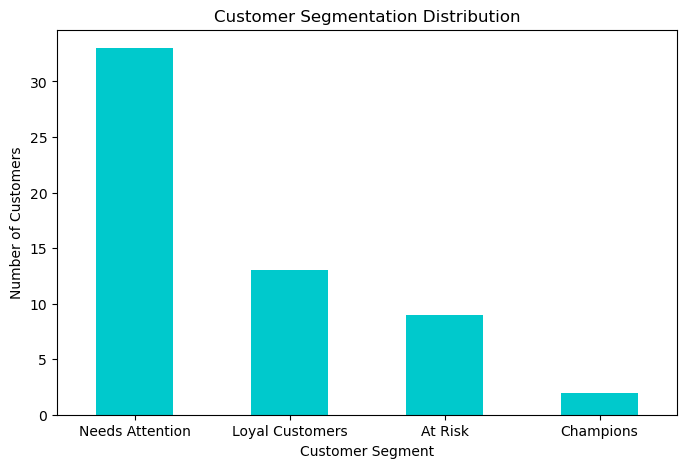

In [57]:
plt.figure(figsize=(8,5))
segment_count.plot(kind="bar", color='#00c9cc')
plt.title("Customer Segmentation Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=360)
plt.show()

## Pareto Analysis

In [58]:
customer_revenue = final_dataset[["customer_id","first_name","total_spending"]].copy()
customer_revenue.rename(columns = {"total_spending": "total_revenue", "first_name": "customer_name"}, inplace=True)

## Sorting Customers by Revenue

In [59]:
customer_revenue = customer_revenue.sort_values(by="total_revenue", ascending=False)

## Calculating Cumulative Revenue
### Step 1: Calculating total business revenue

In [60]:
total_business_revenue = customer_revenue["total_revenue"].sum()

### Step 2: Calculating each customer's percentage contribuation

In [61]:
customer_revenue["revenue_percent"] = customer_revenue["total_revenue"] / total_business_revenue

In [62]:
customer_revenue["cumulative_percent"] = customer_revenue["revenue_percent"].cumsum()
customer_revenue

,customer_id,customer_name,total_revenue,revenue_percent,cumulative_percent
27,1030,Sina,25000.00,0.118265,0.118265
40,1044,Mina,14354.34,0.067905,0.186169
53,1057,Maryam,13532.74,0.064018,0.250187
10,1012,Arash,11731.50,0.055497,0.305684
8,1009,Kimia,11615.42,0.054948,0.360632
55,1059,Ali,8898.55,0.042095,0.402727
46,1050,Reza,6198.00,0.029320,0.432048
3,1004,Sina,6121.45,0.028958,0.461006
51,1055,Mina,6068.22,0.028706,0.489712
32,1035,Arash,5918.21,0.027997,0.517709


## Step 3: Finding the top 20% of Customers

In [63]:
top_20_count = int(len(customer_revenue) * 0.2)
top_20_count

11

In [64]:
top_20_customer = customer_revenue.head(top_20_count)

## Step 4: Calculating The Revenue Generated by The Top 20%

In [65]:
top_20_revenue = top_20_customer["total_revenue"].sum()

top_20_percentage = (top_20_revenue / total_business_revenue) * 100
print(f"Top 20% customers generated {top_20_percentage:.2f}% of total revenue")

Top 20% customers generated 54.52% of total revenue


## Step 5: Checking the 80/20 Rule

In [66]:
if top_20_percentage >= 80:
    print("The dataset follows the Pareto (80/20) principle")
else:
    print("The dataset does not strictly follow the Pareto principle")

The dataset does not strictly follow the Pareto principle


## Step 6: Creating The Pareto Chart

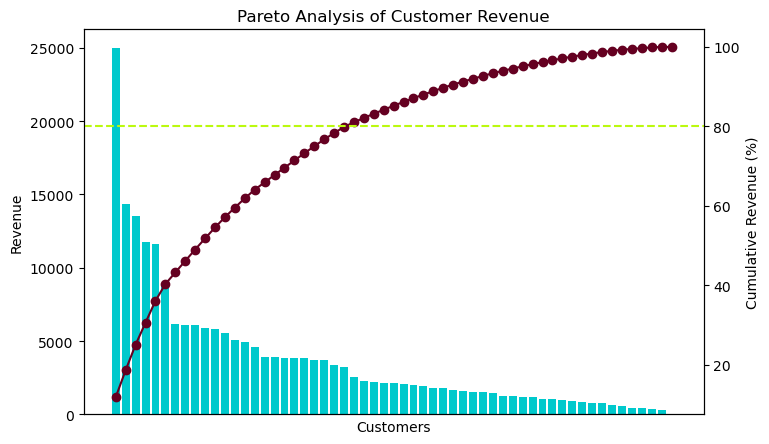

In [67]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(
    range(len(customer_revenue)),
    customer_revenue["total_revenue"],
    color='#00c9cc'
)

ax1.set_xlabel("Customers")
ax1.set_ylabel("Revenue")

ax2 = ax1.twinx()

ax2.plot(
    range(len(customer_revenue)),
    customer_revenue["cumulative_percent"] * 100,
    marker="o",
    color='#650021'
)

ax2.set_ylabel("Cumulative Revenue (%)")
ax2.axhline(80, linestyle="--", color='#BBF90F')

plt.title("Pareto Analysis of Customer Revenue")

plt.xticks([])

plt.show()

## -------------------- Executive Reporting for CEO --------------------

## Chart 1: City Analysis

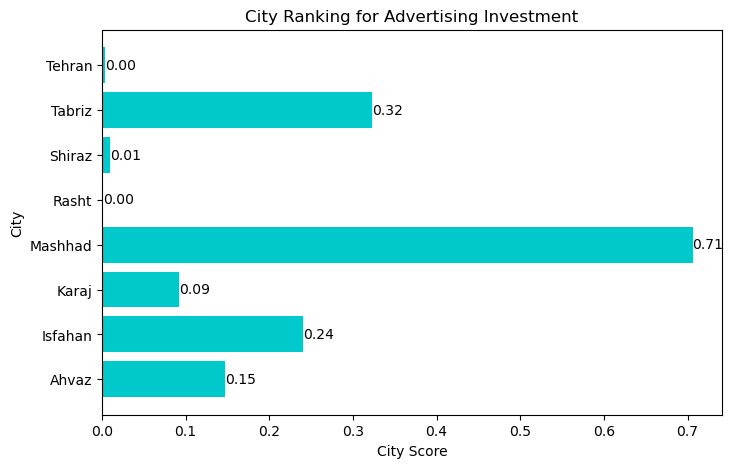

In [68]:
plt.figure(figsize=(8,5))

bars = plt.barh(
    city_analysis.index,
    city_analysis["city_score"],
    color='#00c9cc'
)

for bar in bars:
    plt.text(
    bar.get_width(),
    bar.get_y() + bar.get_height()/2,
    f"{bar.get_width():.2f}",
    va="center"
)
    
plt.xlabel("City Score")
plt.ylabel("City")
plt.title("City Ranking for Advertising Investment")

plt.show()

#### This chart directly supports one of the company's strategic decisions: which city should receive the limited advertising budget. Instead of relying only on total revenue, it evaluates cities using multiple business indicators.

#### The chart ranks cities according to the City Score, which combines:

#### - Total Revenue
#### - Number of Customers
#### - Average Spending
#### - Customer Satisfaction
#### - Return Rate

#### This provides a more balanced evaluation of city performance.

#### Allocate the advertising budget to the city with the highest City Score because it offers the strongest overall business opportunity rather than simply the highest revenue.

## Chart 2: Customer Segmentation

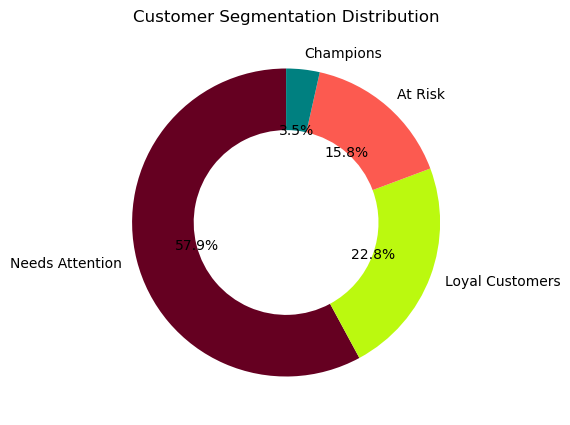

In [69]:
plt.figure(figsize=(8,5))

plt.pie(
    segment_count,
    labels=segment_count.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4},
    colors=[
        "#650021",
        "#BBF90F",
        "#FC5A50",
        "#008080"
    ]
)

plt.title("Customer Segmentation Distribution")

plt.show()

#### Customer retention is usually less expensive than acquiring new customers. This chart helps the CEO understand the overall health of the customer base.

#### The donut chart displays the proportion of customers in four segments:

#### - Champions
#### - Loyal Customers
#### - At Risk
#### - Needs Attention

#### It quickly reveals whether the business has a strong loyal customer base or too many customers requiring attention.

#### If the "At Risk" or "Needs Attention" segments are large, the company should prioritize retention campaigns. If the number of Champions is small, the company should invest in loyalty programs to increase high-value customers.

## Chart 3: Pareto Analysis

#### This analysis shows whether the business depends heavily on a small number of customers, which is an important business risk.

#### The chart compares customer revenue with cumulative revenue contribution.

#### The analysis showed:

#### Top 20% of customers generated approximately 54.5% of total revenue.
#### Therefore, the dataset does not follow the 80/20 Pareto principle.
#### The company should continue building a broad customer base instead of depending on only a few high-value customers. Revenue is relatively well distributed among customers, reducing concentration risk.

## Three Recommendations to Increase Sales
### Recommendation 1:

### Evidence

#### The City Analysis showed that one city achieved the highest overall City Score by combining strong revenue, a large customer base, good spending behavior, and a low return rate.

### Action

#### Prioritize future advertising campaigns and promotional budgets in the highest-ranked city while using its successful marketing strategy as a benchmark for lower-performing cities.

### KPI
#### Revenue growth in the selected city
#### Number of new customers acquired
#### Return on Advertising Investment (ROAS)

### Recommendation 2
### Evidence

#### The Customer Segmentation analysis identified a considerable number of customers in the Needs Attention and At Risk segments.

### Action

#### Launch personalized retention campaigns, including membership upgrades, customized product recommendations, and exclusive offers for high-value customers who have not purchased recently.

### KPI
#### Reduction in At Risk customers
#### Repeat purchase rate
#### Customer retention rate
#### Number of customers moving into the Champions or Loyal Customers segments

### Recommendation 3
### Evidence

#### The Discount Analysis showed that customers who used discounts had:

#### Higher average spending
#### Higher average satisfaction
#### Only a very small increase in return rate
### Action

#### Continue offering discounts, but target them strategically to customer segments that generate the highest additional spending rather than applying discounts to all customers.

### KPI
#### Average order value
#### Revenue generated through discount campaigns
#### Customer satisfaction score
#### Return rate after discount campaigns

## Dataset Limitations

### Limitation 1: No Product Category
#### Without product category information, it is impossible to identify which products contribute most to revenue, returns, or customer satisfaction.

### Suggested Column:
#### Product Category

### Limitation 2: No Profit Information

#### The analysis is based only on revenue. High revenue does not necessarily mean high profitability.

### Suggested Columns:
#### Profit per Order
#### Product Cost

#### This would allow the company to focus on the most profitable customers and cities rather than simply the highest revenue.

### Limitation 3: No Marketing Information

#### The dataset contains no information about how customers were acquired.

### Suggested Columns:
#### Campaign ID
#### Advertising Cost
#### Customer Acquisition Source

#### These variables would allow measurement of marketing effectiveness and return on investment.